# W2D2 — EDA and Visualisation — Lab

**Week 2 · Day 2 · Data Engineering** · Lab

Yesterday you catalogued what is *wrong* with the orders file. Today you ask what it has to *say*.
You will chart the balance of the `returned` target, break the return rate down by every
categorical column you have, look at how the numeric columns move together, and test one question
of your own end to end. Everything you plot today is a candidate feature for D3 — and one or two
of the patterns you find will turn out to be too good to be true. You leave with
`returns_eda_findings.md` and a folder of charts.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٢ اليوم ٢ — الاستكشاف والتمثيل البصري

**الأسبوع ٢ · اليوم ٢ · هندسة البيانات** · معمل عملي

بالأمس فهرست ما هو **خاطئ** في ملف الطلبات. واليوم تسأل عمّا **تقوله** البيانات. سترسم توازن هدف
`returned`، وتوزّع نسبة الإرجاع على كل عمود فئوي لديك، وتنظر في تحرّك الأعمدة الرقمية معًا، وتختبر
سؤالًا من عندك من أوله إلى آخره. وكل ما ترسمه اليوم مرشّح ليكون خاصية في اليوم الثالث — وسيتبيّن
أن نمطًا أو اثنين ممّا تجده أفضل من أن يكون حقيقيًّا. وستخرج بملف `returns_eda_findings.md`
ومجلّد رسوم.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Visualise a binary target's class balance and say what "imbalanced" means for the problem.
- Compute and plot a return rate per category, and judge whether a difference is worth believing given the group sizes.
- Read a correlation matrix, and state plainly why a correlation is not a cause.
- Spot a relationship that is suspiciously strong and explain what makes it suspicious.
- Ask one question of the data, choose the chart that answers it, and write down the answer.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- تمثيل توازن فئات هدف ثنائي بصريًّا، وبيان معنى «غير متوازن» لهذه المسألة.
- حساب ورسم نسبة الإرجاع لكل فئة، والحكم على جدارة الفرق بالتصديق في ضوء أحجام المجموعات.
- قراءة مصفوفة الارتباط، وذكر سبب أن الارتباط ليس سببية بوضوح.
- ملاحظة علاقة قويّة على نحو مريب وشرح ما يجعلها مريبة.
- طرح سؤال واحد على البيانات، واختيار الرسم الذي يجيبه، وتدوين الإجابة.

</div>

## About the data

**Dataset:** `messy_sales` — built for this course · CC0 · 5,000 rows

The same orders file as yesterday, and still uncleaned. One row is one order; the target is
`returned` (1 = the customer sent it back). You are plotting raw data on purpose: charts of dirty
data are themselves evidence, and a few of today's plots will look wrong in a way that points
straight at a cleaning task for tomorrow.

**Watch out:** `city` holds fourteen spellings of five cities. Any chart grouped by `city` will
split one real city across several bars until that is fixed. You will normalise it *for the chart
only* today — the real cleaning belongs to D3.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `messy_sales` — أُعدّت لهذه الدورة · رخصة CC0 · ٥٠٠٠ صف

ملف الطلبات نفسه الذي رأيته بالأمس، وما زال غير منظّف. الصف الواحد طلب واحد، والهدف هو `returned`
(١ تعني أن العميل أعاده). وأنت ترسم البيانات الخام عن قصد: فرسوم البيانات المتّسخة دليل بحدّ ذاته،
وستبدو بعض رسوم اليوم خاطئة بطريقة تشير مباشرة إلى مهمة تنظيف للغد.

**انتبه:** يحمل `city` أربع عشرة تهجئة لخمس مدن. وأي رسم مجمّع حسب `city` سيوزّع المدينة الواحدة
على عدة أعمدة حتى يُصلَح ذلك. وستوحّده **لغرض الرسم فقط** اليوم — أما التنظيف الحقيقي فهو لليوم الثالث.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, and finds the
dataset — whether you are on your own machine or on Google Colab.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتجد ملف البيانات — سواء كنت
على جهازك أو على Google Colab.

</div>

In [1]:
# === AIEP portable setup — works locally (conda) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, device, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("matplotlib", "seaborn")          # charts today, no modelling
seed_everything(42)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

CHART_DIR = ARTEFACT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)

DATA = get_dataset("messy_sales")
print(describe_dataset("messy_sales"))
print("\n", versions(), "| device:", device())

⚠️  Checksum mismatch for messy_sales.csv
  expected: fc71cf3e578ac8a93c823491b70487f461857eefd5ec50348f487677aedd23fb
  actual:   a75cb5f8a8ef10446e07b33eec2df00b2afb12f2642483d57b842b85628d09ae
The file may be corrupt or the registry may be out of date.
📁 messy_sales: using cached file at C:\Users\lojai\Downloads\AIEP_Olo_student\shared\data_cache\messy_sales.csv
messy_sales  (5000 rows, 0.41 MB)
  Source:  Built for this course
  Licence: CC0 (classroom fixture, generated)
  Target:  returned

  EN: Deliberately broken data: missing values in three different patterns, dates in four formats, 120 duplicated rows, fourteen spellings of five cities, and two columns that leak a target. Built so every cleaning technique in W2D3 has something real to fix, and so one dataset carries the whole Week 2 story from data quality through EDA to imbalanced classification. `returned` is 23% positive and genuinely hard — honest features reach AUC ~0.66, while the leaked column reaches ~0.999. Generat

## Section 1 — Warm-up  (≈25 min)

Guided. The code works. Run it, read it, change the one thing each task names, and watch what
moves.

<div dir="rtl" align="right">

## القسم الأول — التهيئة (نحو ٢٥ دقيقة)

قسم موجَّه. الشيفرة تعمل. شغّلها واقرأها، وغيّر الشيء الواحد الذي تسمّيه كل مهمة، وراقب ما يتغيّر.

</div>

In [2]:
# Working code. Nothing to fill in here.
raw = pd.read_csv(DATA)

# Two derived columns we need all day. Both are honest — they use only what was known
# when the order was placed and shipped, and nothing about the outcome.
raw["order_dt"] = pd.to_datetime(raw["order_date"], format="mixed")
raw["ship_dt"] = pd.to_datetime(raw["ship_date"])
raw["ship_delay_days"] = (raw["ship_dt"] - raw["order_dt"]).dt.days

# `city` is normalised for charting only — D3 does this properly and keeps the result.
raw["city_clean"] = raw["city"].str.strip().str.title()

print(f"{len(raw):,} rows | returned rate {raw['returned'].mean():.1%}")
print(f"city: {raw['city'].nunique()} spellings -> {raw['city_clean'].nunique()} cities")
raw[["order_date", "city", "city_clean", "ship_delay_days", "returned"]].head()

5,000 rows | returned rate 23.1%
city: 14 spellings -> 5 cities


,order_date,city,city_clean,ship_delay_days,returned
0,2025-06-12,DAMMAM,Dammam,9,0
1,15 Sep 2024,Riyadh,Riyadh,3,1
2,2025/04/24,TABUK,Tabuk,14,0
3,2024-04-15,riyadh,Riyadh,1,0
4,18 Feb 2025,Abha,Abha,12,0


### Task 1.1 — See the imbalance

The chart below is the single most important picture of the week. Run it.

Then change `normalize` to `False` and re-run. Both charts are true; they answer different
questions. Decide which one you would put in front of a manager who has to decide whether this
problem is worth solving.

<div dir="rtl" align="right">

### المهمة ١٫١ — شاهد الاختلال

الرسم أدناه هو أهم صورة في الأسبوع. شغّله.

ثم غيّر `normalize` إلى `False` وأعد التشغيل. الرسمان صحيحان، لكنهما يجيبان سؤالين مختلفين. قرّر
أيّهما ستضع أمام مدير عليه أن يقرّر هل تستحق هذه المسألة الحل.

</div>

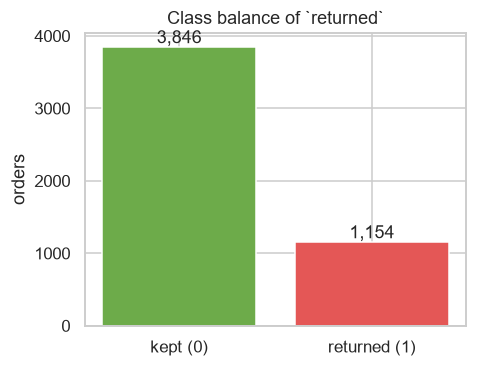

In [3]:
# Change normalize between True and False, then re-run.
normalize = False # True = show share of orders, False = show number of orders

counts = raw["returned"].value_counts(normalize=normalize).sort_index()
labels = ["kept (0)", "returned (1)"]

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar(labels, counts.values, color=["#6DAB4A", "#E45756"])
ax.set_title("Class balance of `returned`")
ax.set_ylabel("share of orders" if normalize else "orders")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:.1%}" if normalize else f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

### Task 1.2 — A rate is a mean

Because `returned` is coded 0/1, the **mean** of the column inside any group *is* that group's
return rate. That one fact is what makes the rest of today's analysis a one-liner.

Change `by` to `"customer_tier"` and then to `"city_clean"` and re-run each time.

<div dir="rtl" align="right">

### المهمة ١٫٢ — النسبة هي المتوسّط

لأن `returned` مرمّز بصفر وواحد، فإن **متوسّط** العمود داخل أي مجموعة **هو** نسبة الإرجاع في تلك
المجموعة. وهذه الحقيقة وحدها تجعل بقية تحليل اليوم سطرًا واحدًا.

غيّر `by` إلى `"customer_tier"` ثم إلى `"city_clean"`، وأعد التشغيل في كل مرة.

</div>

In [5]:
# Change `by` and re-run.

by = "city_clean"


summary = raw.groupby(by)["returned"].agg(return_rate="mean", orders="size")
print(summary.to_string(formatters={"return_rate": "{:.1%}".format}))

           return_rate  orders
city_clean                    
Abha             22.9%     507
Dammam           23.9%     867
Jeddah           22.0%    1300
Riyadh           23.7%    1747
Tabuk            22.6%     579


## Section 2 — Core  (≈60 min)

This is the lab. Each task has a goal; you write the code. Save each finished chart into
`CHART_DIR` — the artefact at the end collects them.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي (نحو ٦٠ دقيقة)

هذا هو صلب المعمل. لكل مهمة هدف، وأنت من يكتب الشيفرة. احفظ كل رسم منتهٍ في `CHART_DIR` — فالمخرج
في النهاية يجمعها.

</div>

### Task 2.1 — Return rate by every category, on one figure

Build a figure with one panel per categorical column — `channel`, `customer_tier` and
`city_clean` — each showing the return rate per category as a bar chart.

Draw the overall return rate as a horizontal reference line on every panel. Without it a reader
cannot tell whether a bar is high or the whole dataset is high, and that reference line is the
difference between a chart that informs and a chart that decorates.

<div dir="rtl" align="right">

### المهمة ٢٫١ — نسبة الإرجاع لكل فئة في شكل واحد

ابنِ شكلًا فيه لوحة لكل عمود فئوي — `channel` و`customer_tier` و`city_clean` — تُظهر كل لوحة نسبة
الإرجاع لكل فئة كرسم أعمدة.

وارسم نسبة الإرجاع الإجمالية كخط مرجعي أفقي في كل لوحة. فبدونه لا يستطيع القارئ تمييز ما إذا كان
العمود مرتفعًا أم أن المجموعة كلها مرتفعة، وهذا الخط المرجعي هو الفرق بين رسم يُعلم ورسم يزيّن.

</div>

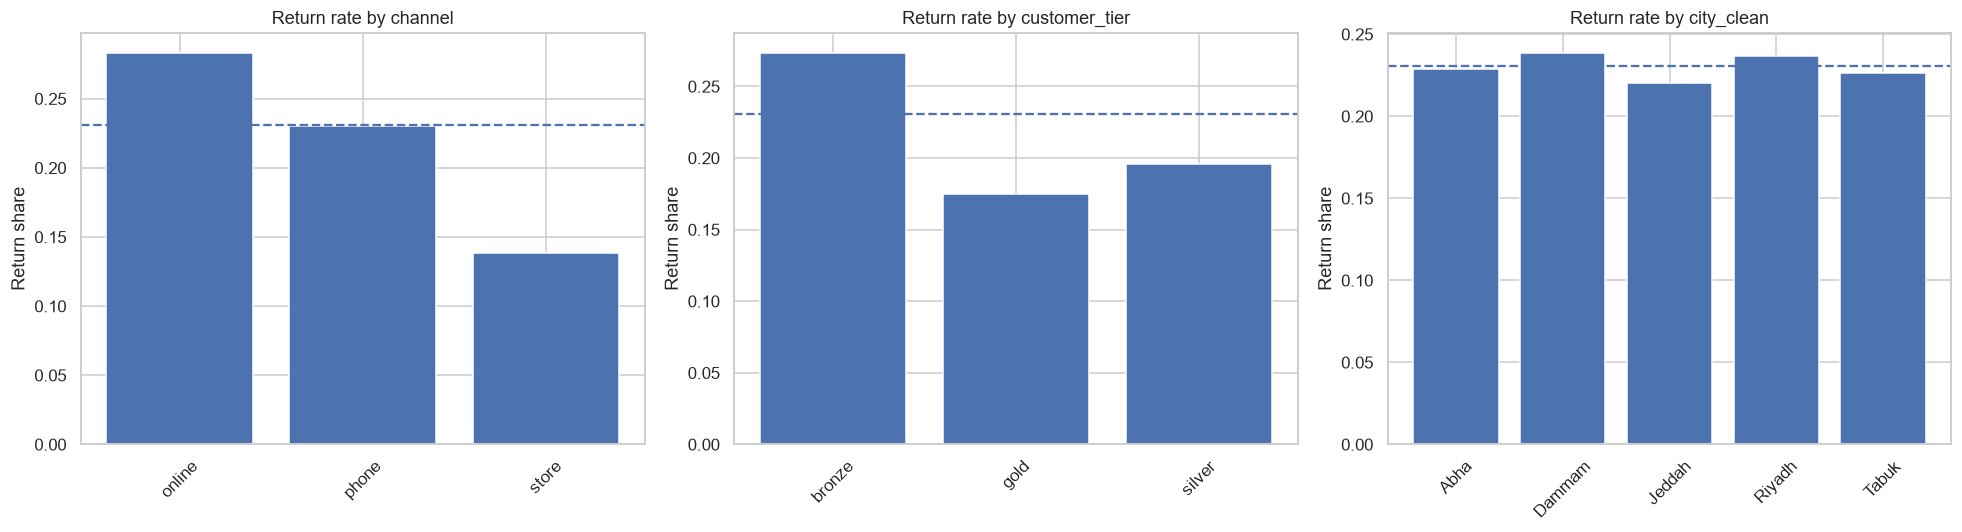

--- channel ---
channel
online   28.3%
phone    23.1%
store    13.9% 

--- customer_tier ---
customer_tier
bronze   27.4%
gold     17.5%
silver   19.6% 

--- city_clean ---
city_clean
Abha     22.9%
Dammam   23.9%
Jeddah   22.0%
Riyadh   23.7%
Tabuk    22.6% 



In [8]:
CATEGORICAL = ["channel", "customer_tier", "city_clean"]
overall = raw["returned"].mean()

# Calculate the return rate for each categorical column
rate_tables = {}

for col in CATEGORICAL:
    rate_tables[col] = raw.groupby(col)["returned"].mean()

# Create one subplot for each categorical column
fig, axes = plt.subplots(
    1,
    len(CATEGORICAL),
    figsize=(18, 5)
)

# Draw the return rate for each category
for ax, col in zip(axes, CATEGORICAL):
    rates = rate_tables[col]

    # Draw the return rates as bars
    ax.bar(rates.index, rates.values)

    # Add the overall return rate as a reference line
    ax.axhline(overall, linestyle="--")

    # Label the chart
    ax.set_title(f"Return rate by {col}")
    ax.set_ylabel("Return share")

    # Rotate labels so they are readable
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

# Save the finished chart
plt.savefig(
    CHART_DIR / "return_rate_by_category.png",
    bbox_inches="tight"
)

plt.show()

# Print the return-rate tables
for col, rates in rate_tables.items():
    print(f"--- {col} ---")
    print(
        rates.to_string(float_format="{:.1%}".format),
        "\n"
    )

### Task 2.2 — Is the difference big enough to believe?

Your best category from 2.1 has a higher return rate than the worst. Before you believe it, check
how many orders each bar is standing on.

Produce one table per categorical column with the return rate **and** the number of orders, sorted
by rate. Then answer the question in the markdown cell: is there any group whose rate you would
not quote to a manager, and why?

<div dir="rtl" align="right">

### المهمة ٢٫٢ — هل الفرق كبير بما يكفي للتصديق؟

فئتك الأفضل في المهمة ٢٫١ لها نسبة إرجاع أعلى من الأسوأ. وقبل أن تصدّق ذلك، تحقّق من عدد الطلبات
التي يقف عليها كل عمود.

أنتج جدولًا لكل عمود فئوي فيه نسبة الإرجاع **و**عدد الطلبات، مرتّبًا حسب النسبة. ثم أجب في خلية
Markdown: هل هناك مجموعة لن تذكر نسبتها لمدير، ولماذا؟

</div>

In [9]:
# ────────────────────────────────────────────────────────────────────
# 1) `agg` can compute several things at once — ask it for the mean and the size.
# 2) Name the outputs so the columns read as "return_rate" and "orders".
# 3) Sort by rate so the extremes are at the ends, and print all three tables.
# Search: "pandas groupby agg named aggregation"
# https://pandas.pydata.org/docs/user_guide/groupby.html#named-aggregation
#
# ١) يستطيع `agg` حساب أشياء عدة دفعة واحدة — اطلب منه المتوسّط والحجم.
# ٢) سمِّ المخرجات بحيث تُقرأ الأعمدة «return_rate» و«orders».
# ٣) رتّب حسب النسبة ليكون الطرفان في النهايتين، واطبع الجداول الثلاثة.
# ابحث عن: "pandas groupby agg named aggregation"
# ────────────────────────────────────────────────────────────────────

# TODO: For each categorical column build a table of return rate and order count, sorted by rate, and print it.
# مهمة: ابنِ لكل عمود فئوي جدولًا بنسبة الإرجاع وعدد الطلبات، مرتّبًا حسب النسبة، واطبعه.
group_tables = {}

for col in CATEGORICAL:
    group_tables[col] = (
        raw.groupby(col)["returned"]
        .agg(return_rate="mean", orders="size")
        .sort_values("return_rate")
    )


for col, table in group_tables.items():
    print(f"--- {col} ---")
    print(table.to_string(formatters={"return_rate": "{:.1%}".format}), "\n")

--- channel ---
        return_rate  orders
channel                    
store         13.9%    1551
phone         23.1%     720
online        28.3%    2729 

--- customer_tier ---
              return_rate  orders
customer_tier                    
gold                17.5%     766
silver              19.6%    1785
bronze              27.4%    2449 

--- city_clean ---
           return_rate  orders
city_clean                    
Jeddah           22.0%    1300
Tabuk            22.6%     579
Abha             22.9%     507
Riyadh           23.7%    1747
Dammam           23.9%     867 



**Your answer.** Which group's rate would you refuse to quote, and what would you say instead?

*(Replace this with two sentences of your own.)*

<div dir="rtl" align="right">

**إجابتك.** ما المجموعة التي سترفض ذكر نسبتها، وماذا ستقول بدلًا من ذلك؟
All groups have hundreds of orders, so none of the return rates are based on a very small sample. However, groups with fewer orders, such as Abha and Tabuk, should still be interpreted more carefully
</div>

### Task 2.3 — Compare a numeric column across the two classes

Pick a numeric column that exists at order time — `unit_price`, `quantity` or `ship_delay_days` —
and show its distribution **split by** `returned`, so a reader can see whether returned orders
look different from kept ones.

A box plot or a pair of overlaid histograms both work. Whichever you choose, the two classes must
be visually comparable: the returned class is only 23% of the data, so raw overlaid counts will
make it look like nothing is there. Think about what to normalise.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — قارن عمودًا رقميًّا بين الفئتين

اختر عمودًا رقميًّا متاحًا وقت الطلب — `unit_price` أو `quantity` أو `ship_delay_days` — وأظهر
توزيعه **مقسومًا حسب** `returned`، ليرى القارئ هل تبدو الطلبات المُرجعة مختلفة عن المحتفظ بها.

يصلح رسم الصندوق أو مدرّجان متراكبان. وأيًّا كان اختيارك، يجب أن تكون الفئتان قابلتين للمقارنة
بصريًّا: فالفئة المُرجعة ٢٣٪ فقط من البيانات، والأعداد الخام المتراكبة ستُظهرها وكأنها غير موجودة.
ففكّر فيما ينبغي تطبيعه.

</div>

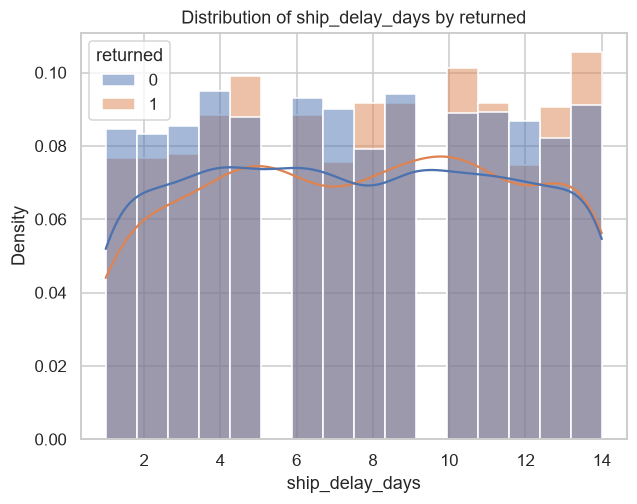

median ship_delay_days — kept: 7.00   returned: 8.00


In [19]:
# ────────────────────────────────────────────────────────────────────
# 1) Choose one numeric column that is known at order time.
# 2) Draw its distribution for returned == 0 and returned == 1 on the same axes.
# 3) The classes are different sizes, so compare shapes, not counts — look for the
#    seaborn argument that turns a histogram into a density, or use a box plot.
# 4) Print the median of the column for each class underneath, so the picture has a number.
# Search: "seaborn histplot common_norm stat density hue"
# https://seaborn.pydata.org/generated/seaborn.histplot.html
#
# ١) اختر عمودًا رقميًّا واحدًا معروفًا وقت الطلب.
# ٢) ارسم توزيعه عند returned == 0 وعند returned == 1 على المحاور نفسها.
# ٣) حجما الفئتين مختلفان، فقارن الأشكال لا الأعداد — ابحث عن وسيط seaborn الذي
#    يحوّل المدرّج إلى كثافة، أو استخدم رسم الصندوق.
# ٤) اطبع وسيط العمود لكل فئة أسفل الرسم، ليحمل الشكل رقمًا.
# ابحث عن: "seaborn histplot common_norm stat density hue"
# ────────────────────────────────────────────────────────────────────

NUMERIC_CHOICE = "ship_delay_days" 
# TODO: Plot the distribution of your chosen column split by `returned`, made comparable across the two unequal class sizes. 
medians = raw.groupby("returned")[NUMERIC_CHOICE].median() 
 
sns.histplot( 
    data=raw, 
    x=NUMERIC_CHOICE, 
    hue="returned", 
    stat="density", 
    common_norm=False, 
    kde=True 
) 
 
plt.title(f"Distribution of {NUMERIC_CHOICE} by returned") 
plt.xlabel(NUMERIC_CHOICE) 
plt.ylabel("Density")

# Save the chart
plt.savefig(CHART_DIR / "ship_delay_by_returned.png", bbox_inches="tight")

plt.show() 
print(f"median {NUMERIC_CHOICE} — kept: {medians[0]:.2f}   returned: {medians[1]:.2f}")

### Task 2.4 — The correlation matrix, and what it cannot tell you

Compute the correlation matrix of the numeric columns **including `returned`**, and draw it as a
heatmap.

Read it in this order: first look for pairs that are near ±1, because those are usually the same
information twice; then read the `returned` row; then stop. Do not go hunting through all
sixty-odd cells for the biggest number — that is how people find patterns that are not there.

One pair will be at almost exactly 1.0, and one column will predict `returned` far better than
anything else. Note both down. You are not fixing them today.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — مصفوفة الارتباط، وما لا تستطيع إخبارك به

احسب مصفوفة ارتباط الأعمدة الرقمية **متضمّنة `returned`**، وارسمها كخريطة حرارية.

اقرأها بهذا الترتيب: ابحث أولًا عن الأزواج القريبة من ±١، فهي عادةً المعلومة نفسها مرتين؛ ثم اقرأ
صف `returned`؛ ثم توقّف. ولا تفتّش في الخلايا الستين بحثًا عن أكبر رقم — فهكذا يجد الناس أنماطًا
غير موجودة.

سيكون أحد الأزواج عند ١٫٠ تقريبًا، وسيتنبّأ عمود واحد بـ`returned` أفضل بكثير من أي عمود آخر.
دوّنهما معًا. ولن تصلحهما اليوم.

</div>

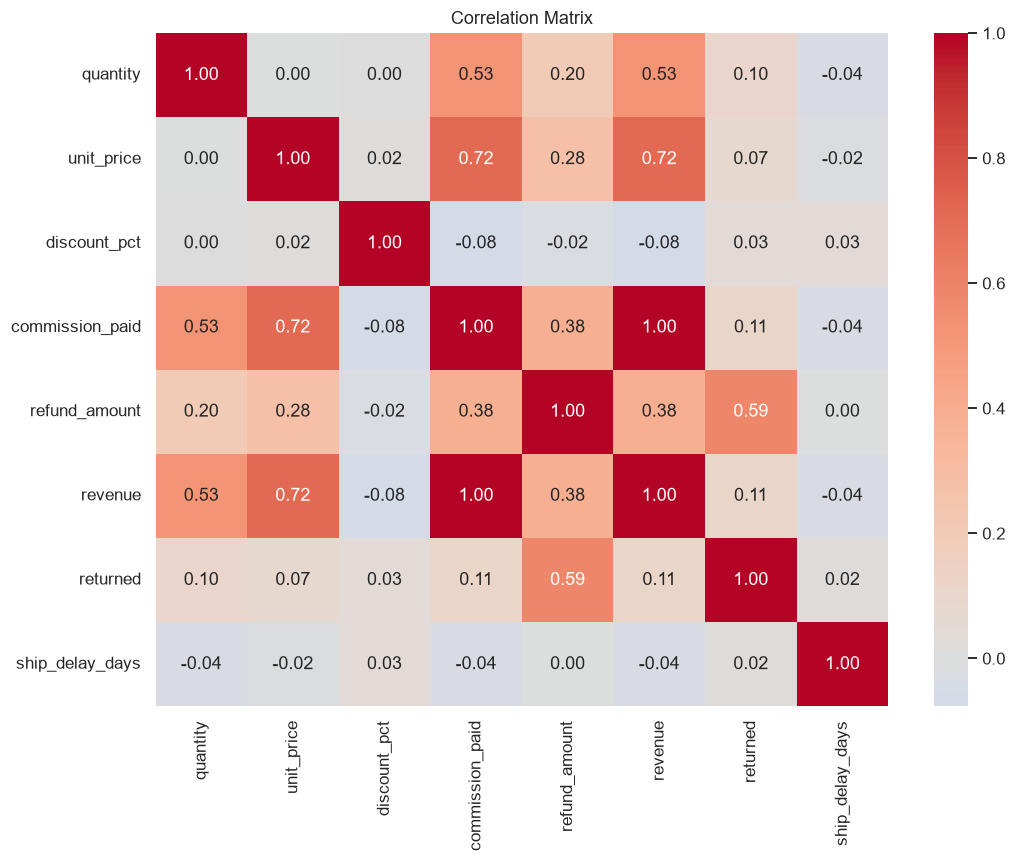

correlation with `returned`, strongest first:
refund_amount     +0.589
revenue           +0.108
commission_paid   +0.108
quantity          +0.104
unit_price        +0.071
discount_pct      +0.033
ship_delay_days   +0.022


In [20]:
# ────────────────────────────────────────────────────────────────────
# 1) Select the numeric columns, but drop the ones that are identifiers rather than
#    measurements — an order id has no meaningful correlation with anything.
# 2) Compute the correlation matrix and draw it with a diverging colour map centred
#    on zero, so positive and negative are visually distinct.
# 3) Annotate the cells; an unlabelled heatmap cannot be read precisely.
# 4) Print the `returned` row on its own, sorted, so the ranking is explicit.
# Search: "seaborn heatmap annot corr diverging"
# https://seaborn.pydata.org/generated/seaborn.heatmap.html
#
# ١) اختر الأعمدة الرقمية، واستبعد ما هو معرّف لا قياس — فرقم الطلب لا ارتباط
#    ذا معنى له بأي شيء.
# ٢) احسب مصفوفة الارتباط وارسمها بخريطة ألوان متباعدة مركزها الصفر، ليتمايز
#    الموجب عن السالب بصريًّا.
# ٣) اكتب القيم داخل الخلايا؛ فالخريطة بلا تسميات لا تُقرأ بدقّة.
# ٤) اطبع صف `returned` وحده مرتّبًا، ليكون الترتيب صريحًا.
# ابحث عن: "seaborn heatmap annot corr diverging"
# ────────────────────────────────────────────────────────────────────

DROP_FROM_CORR = ["order_id"]

# TODO: Build and plot the correlation matrix of the numeric columns including `returned`, then print the `returned` row sorted by absolute strength.

# Select numeric columns and remove identifier columns
numeric = raw.select_dtypes(include="number").drop(columns=DROP_FROM_CORR)

# Compute the correlation matrix
corr = numeric.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()

# Save the chart
plt.savefig(CHART_DIR / "correlation_matrix.png", bbox_inches="tight")

plt.show()

# Sort correlations with returned by absolute strength
returned_corr = (
    corr["returned"]
    .drop("returned")
    .sort_values(key=abs, ascending=False)
)

print("correlation with `returned`, strongest first:")
print(returned_corr.to_string(float_format="{:+.3f}".format))

### Task 2.5 — Interrogate the suspicious column

The `returned` row has one column far ahead of the rest. Look at it directly: plot its
distribution for kept orders against returned orders, and print what share of each class has a
value of zero.

Then think about the order of events in a shop. When does that number get written down? Could you
have had it at the moment the order was placed?

You are not removing it today — D3 does that, and gives it its proper name. Today you only have to
notice that it is strange.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — استجوب العمود المريب

في صف `returned` عمود يسبق البقية بفارق كبير. انظر إليه مباشرة: ارسم توزيعه للطلبات المحتفظ بها
مقابل المُرجعة، واطبع نسبة كل فئة التي قيمتها صفر.

ثم فكّر في ترتيب الأحداث في متجر. متى يُكتب هذا الرقم؟ وهل كان بإمكانك امتلاكه لحظة تقديم الطلب؟

لن تحذفه اليوم — فاليوم الثالث يفعل ذلك ويعطيه اسمه الصحيح. وكل ما عليك اليوم هو ملاحظة غرابته.

</div>

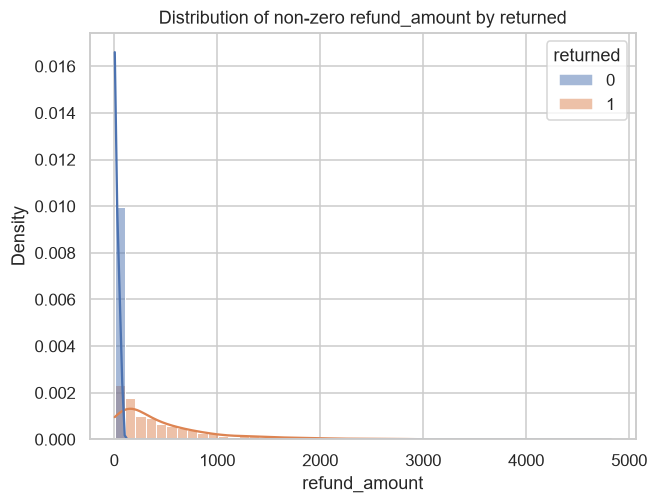

share of each class with refund_amount == 0:
returned
0   99.9%
1    0.4%

correlation with returned: +0.589


In [21]:
# ────────────────────────────────────────────────────────────────────
# 1) Take the column at the top of your `returned` correlation ranking.
# 2) Show what share of the kept orders and what share of the returned orders
#    have a value of exactly zero. The gap is the whole story.
# 3) Plot the non-zero values for each class so the chart is not one giant bar at zero.
# Search: "pandas groupby share equal to zero"
#
# ١) خذ العمود الأعلى في ترتيب ارتباطك بـ`returned`.
# ٢) أظهر نسبة الطلبات المحتفظ بها ونسبة الطلبات المُرجعة التي قيمتها صفر
#    تمامًا. والفجوة هي القصة كلها.
# ٣) ارسم القيم غير الصفرية لكل فئة كي لا يكون الرسم عمودًا ضخمًا عند الصفر.
# ابحث عن: "pandas groupby share equal to zero"
# ────────────────────────────────────────────────────────────────────

SUSPECT = "refund_amount"
# TODO: Report the share of each class whose SUSPECT value is exactly zero, and plot the non-zero values split by class.

# Calculate the share of zero values in each class
zero_share = raw.groupby("returned")[SUSPECT].apply(lambda x: (x == 0).mean())

# Keep only non-zero values
non_zero = raw[raw[SUSPECT] != 0]

# Plot non-zero values split by returned
sns.histplot(
    data=non_zero,
    x=SUSPECT,
    hue="returned",
    stat="density",
    common_norm=False,
    kde=True
)

plt.title(f"Distribution of non-zero {SUSPECT} by returned")
plt.xlabel(SUSPECT)
plt.ylabel("Density")

# Save the chart
plt.savefig(CHART_DIR / "refund_amount_by_returned.png", bbox_inches="tight")

plt.show()

print(f"share of each class with {SUSPECT} == 0:")
print(zero_share.to_string(float_format="{:.1%}".format))
print(f"\ncorrelation with returned: {raw[SUSPECT].corr(raw['returned']):+.3f}")

**Write it down.** When does `refund_amount` become known, relative to the moment you would need
to predict `returned`? In one sentence, why would a model that uses it look excellent and be
useless?

*(Your answer here.)*

<div dir="rtl" align="right">

**دوّنها.** متى تصبح قيمة `refund_amount` معروفة، نسبةً إلى اللحظة التي تحتاج فيها التنبّؤ
بـ`returned`؟ وفي جملة واحدة: لماذا سيبدو النموذج الذي يستخدمه ممتازًا ويكون عديم الفائدة؟

refund_amount becomes known after a return/refund occurs, not when the order is placed. A model using it would look excellent because it uses information from after the outcome, but it would be useless for predicting returns at order time.
</div>

### Task 2.6 — Correlation is not cause

Pick the strongest **honest** relationship from your `returned` correlation row — not the suspect
column — and write down two different explanations for it.

One should be "this causes returns". The other should be a story where the relationship is real
but the cause is something else entirely, or the arrow points the other way.

There is no code to write beyond printing the number you are discussing. The skill is the second
explanation: a habit of asking "what else would produce this same correlation?" is worth more than
any chart you have drawn today.

<div dir="rtl" align="right">

### المهمة ٢٫٦ — الارتباط ليس سببية

اختر أقوى علاقة **نزيهة** من صف ارتباطك بـ`returned` — لا العمود المريب — واكتب لها تفسيرين مختلفين.

أحدهما «هذا يسبّب الإرجاع». والآخر قصة تكون فيها العلاقة حقيقية لكن السبب شيء آخر تمامًا، أو يكون
اتجاه السهم معكوسًا.

لا شيفرة تُكتب هنا سوى طباعة الرقم الذي تناقشه. والمهارة في التفسير الثاني: فعادة السؤال «ما الذي
قد يُنتج هذا الارتباط نفسه أيضًا؟» أثمن من أي رسم رسمته اليوم.

</div>

In [13]:
# ────────────────────────────────────────────────────────────────────
# 1) Drop the suspect column from the ranking you already computed.
# 2) Print what is left, strongest first. The top honest row is the one to discuss.
#
# ١) احذف العمود المريب من الترتيب الذي حسبته بالفعل.
# ٢) اطبع ما تبقّى من الأقوى. والصف النزيه الأعلى هو موضوع النقاش.
# ────────────────────────────────────────────────────────────────────

# TODO: Print the correlation ranking with the leaking column removed.
honest_corr = returned_corr.drop(SUSPECT)
print("honest correlations with `returned`:")
print(honest_corr.to_string(float_format="{:+.3f}".format))

honest correlations with `returned`:
revenue           +0.108
commission_paid   +0.108
quantity          +0.104
unit_price        +0.071
discount_pct      +0.033
ship_delay_days   +0.022


**The relationship I am explaining:** *(name it, and give the number)*

1. **If it were causal:** *(one sentence)*
2. **A different explanation that fits the same number:** *(one sentence)*

<div dir="rtl" align="right">

**العلاقة التي أفسّرها:** *(سمِّها واذكر الرقم)*

١. **لو كانت سببية:** *(جملة واحدة)*
٢. **تفسير مختلف يناسب الرقم نفسه:** *(جملة واحدة)*
The relationship I am explaining: revenue and returned, correlation = +0.108.

If it were causal: Higher-revenue orders may be more likely to be returned because customers may reconsider more expensive purchases.
A different explanation that fits the same number: Larger orders may increase both revenue and the chance that at least one item is returned.
</div>

## Section 3 — Stretch  (≈30 min)

Open-ended, and lower expectation of completeness.

Ask a question that needs **two** columns at once — something like "are deep discounts only risky
on one channel?" or "does slow shipping hurt more for bronze customers than gold ones?" — and
answer it with a grouped chart or a pivot table.

Two-way questions are where the useful features come from. A column that does nothing on its own
can matter a great deal inside one group, and you will not find that by plotting one column at a
time.

**Link to your capstone:** when you get to feature engineering on your own project, the
interactions you find this way are the features worth building. Note anything promising — D3 is
where you turn it into a column.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل.

اطرح سؤالًا يحتاج **عمودين** معًا — مثل «هل الخصومات الكبيرة خطرة على قناة واحدة فقط؟» أو «هل يضرّ
الشحن البطيء عملاء المستوى البرونزي أكثر من الذهبي؟» — وأجبه برسم مجمّع أو جدول محوري.

الأسئلة الثنائية هي منبع الخصائص المفيدة. فالعمود الذي لا يفعل شيئًا وحده قد يكون بالغ الأهمية
داخل مجموعة واحدة، ولن تجد ذلك برسم عمود واحد في كل مرة.

**الصلة بمشروعك:** حين تصل إلى هندسة الخصائص في مشروعك، تكون التفاعلات التي تجدها بهذه الطريقة هي
الخصائص الجديرة بالبناء. دوّن كل ما يبدو واعدًا — واليوم الثالث هو حيث تحوّله إلى عمود.

</div>

In [14]:
# ────────────────────────────────────────────────────────────────────
# There is no single right answer. Pick two columns, cut any continuous one into a
# few buckets, then group by both and take the mean of `returned`. A pivot table or
# a heatmap reads better than a long list. Print the group sizes too — a two-way
# split makes small groups fast, and a rate over 20 rows is not a finding.
#
# لا توجد إجابة واحدة صحيحة. اختر عمودين، وقسّم أي عمود متّصل إلى بضع سلال، ثم
# جمّع حسب الاثنين وخذ متوسّط `returned`. والجدول المحوري أو الخريطة الحرارية
# أسهل قراءة من قائمة طويلة. واطبع أحجام المجموعات أيضًا — فالتقسيم الثنائي
# يصغّر المجموعات بسرعة، والنسبة على عشرين صفًّا ليست نتيجة.
# ────────────────────────────────────────────────────────────────────

# TODO: Investigate one two-column question and show the result as a pivot table or chart.
# Create shipping delay groups
raw["ship_delay_group"] = pd.cut(
    raw["ship_delay_days"],
    bins=[0, 3, 7, 14],
    labels=["1-3 days", "4-7 days", "8-14 days"],
    include_lowest=True
)

# Calculate return rate and group size
two_way = (
    raw.groupby(
        ["customer_tier", "ship_delay_group"],
        observed=False
    )["returned"]
    .agg(return_rate="mean", orders="size")
)

# Show return rates as a pivot table
rate_pivot = two_way["return_rate"].unstack()
print("Return rate:")
print(rate_pivot.to_string(float_format="{:.1%}".format))

# Show group sizes
orders_pivot = two_way["orders"].unstack()
print("\nOrders:")
print(orders_pivot.to_string())

Return rate:
ship_delay_group  1-3 days  4-7 days  8-14 days
customer_tier                                  
bronze               25.6%     26.3%      28.7%
gold                 13.6%     16.9%      19.1%
silver               18.5%     19.4%      20.2%

Orders:
ship_delay_group  1-3 days  4-7 days  8-14 days
customer_tier                                  
bronze                 515       722       1212
gold                   125       237        404
silver                 368       515        902


## Save your artefact

`returns_eda_findings.md` is what D3 reads before deciding what to clean and what to build. Write
down the patterns worth keeping and the one column you distrust, with the numbers you actually
measured. The charts go beside it in `charts/`.

<div dir="rtl" align="right">

## احفظ مخرجاتك

ملف `returns_eda_findings.md` هو ما يقرؤه اليوم الثالث قبل أن يقرّر ما يُنظَّف وما يُبنى. دوّن
الأنماط الجديرة بالإبقاء والعمود الوحيد الذي لا تثق به، بالأرقام التي قِستها فعلًا. وتوضع الرسوم
بجواره في `charts/`.

</div>

In [22]:
# Build the markdown report from the results already computed
findings = f"""# Returns EDA Findings

## Overall return rate
The overall return rate is {overall:.1%}.

## Return rate by category

### Channel
{group_tables["channel"].to_string(formatters={"return_rate": "{:.1%}".format})}

### Customer tier
{group_tables["customer_tier"].to_string(formatters={"return_rate": "{:.1%}".format})}

### City
{group_tables["city_clean"].to_string(formatters={"return_rate": "{:.1%}".format})}

## Shipping delay
Median shipping delay for kept orders: {medians[0]:.2f} days.
Median shipping delay for returned orders: {medians[1]:.2f} days.

## Correlation with returned
{returned_corr.to_string(float_format="{:+.3f}".format)}

## Suspicious column
The suspicious column is `{SUSPECT}`.

Correlation with returned: {raw[SUSPECT].corr(raw["returned"]):+.3f}

Share with zero {SUSPECT}:
{zero_share.to_string(float_format="{:.1%}".format)}

`{SUSPECT}` becomes known after the return/refund outcome, so it would not be available when predicting returns at order time.

## Honest correlations
{honest_corr.to_string(float_format="{:+.3f}".format)}

## Two-column investigation

### Return rate by customer tier and shipping delay
{rate_pivot.to_string(float_format="{:.1%}".format)}

### Number of orders
{orders_pivot.to_string()}

## Saved charts
{chr(10).join(f"- {p.name}" for p in sorted(CHART_DIR.glob("*.png")))}
"""

# Save the report
out = ARTEFACT_DIR / "returns_eda_findings.md"
out.write_text(findings, encoding="utf-8")

print(f"Saved {out} and {len(list(CHART_DIR.glob('*.png')))} charts\n")
print(out.read_text(encoding="utf-8"))

Saved c:\Users\lojai\Downloads\AIEP_Olo_student\week_2_data_engineering\labs_v2\D2_eda_and_visualisation\artefacts\returns_eda_findings.md and 4 charts

# Returns EDA Findings

## Overall return rate
The overall return rate is 23.1%.

## Return rate by category

### Channel
        return_rate  orders
channel                    
store         13.9%    1551
phone         23.1%     720
online        28.3%    2729

### Customer tier
              return_rate  orders
customer_tier                    
gold                17.5%     766
silver              19.6%    1785
bronze              27.4%    2449

### City
           return_rate  orders
city_clean                    
Jeddah           22.0%    1300
Tabuk            22.6%     579
Abha             22.9%     507
Riyadh           23.7%    1747
Dammam           23.9%     867

## Shipping delay
Median shipping delay for kept orders: 7.00 days.
Median shipping delay for returned orders: 8.00 days.

## Correlation with returned
refund_amount   

## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [23]:
# --- Sanity checks ----------------------------------------------------------------

check(0.20 < overall < 0.26,
      f"the overall return rate should be about 23%, you measured {overall:.1%}",
      f"يجب أن تكون نسبة الإرجاع الإجمالية نحو ٢٣٪، وقد قِست {overall:.1%}")

check(all(set(t.columns) == {"return_rate", "orders"} for t in group_tables.values()),
      "each category table needs both a return_rate and an orders column",
      "يحتاج كل جدول فئة إلى عمودَي return_rate وorders معًا")

check(raw["city_clean"].nunique() < raw["city"].nunique(),
      f"normalising city should reduce {raw['city'].nunique()} spellings, "
      f"you got {raw['city_clean'].nunique()}",
      f"يجب أن يقلّل توحيد city عدد التهجئات من {raw['city'].nunique()}، "
      f"وقد حصلت على {raw['city_clean'].nunique()}")

check(abs(returned_corr.iloc[0]) > abs(honest_corr.iloc[0]) + 0.10,
      f"the suspect column should stand well clear of the honest ones: "
      f"{returned_corr.iloc[0]:+.3f} vs {honest_corr.iloc[0]:+.3f}",
      f"يجب أن يتقدّم العمود المريب على النزيهة بوضوح: "
      f"{returned_corr.iloc[0]:+.3f} مقابل {honest_corr.iloc[0]:+.3f}")

check(zero_share[0] > 0.90 and zero_share[1] < 0.10,
      f"refund_amount should be zero for nearly all kept orders ({zero_share[0]:.1%}) "
      f"and almost no returned ones ({zero_share[1]:.1%})",
      f"يجب أن يكون refund_amount صفرًا لمعظم الطلبات المحتفظ بها ({zero_share[0]:.1%}) "
      f"ولأقلّ القليل من المُرجعة ({zero_share[1]:.1%})")

check(len(list(CHART_DIR.glob("*.png"))) >= 4,
      f"you should have saved at least 4 charts, found "
      f"{len(list(CHART_DIR.glob('*.png')))}",
      f"يجب أن تكون قد حفظت أربعة رسوم على الأقل، ووُجد "
      f"{len(list(CHART_DIR.glob('*.png')))}")

check((ARTEFACT_DIR / "returns_eda_findings.md").exists(),
      "returns_eda_findings.md should exist in artefacts/ — D3 reads it tomorrow",
      "يجب أن يوجد returns_eda_findings.md في artefacts/ — يقرؤه اليوم الثالث غدًا")

report()

──────────────────────────────────────────────────────────────────
  ✓  the overall return rate should be about 23%, you measured 23.1%
  ✓  each category table needs both a return_rate and an orders column
  ✓  normalising city should reduce 14 spellings, you got 5
  ✓  the suspect column should stand well clear of the honest ones: +0.589 vs +0.108
  ✓  refund_amount should be zero for nearly all kept orders (99.9%) and almost no returned ones (0.4%)
  ✓  you should have saved at least 4 charts, found 4
  ✓  returns_eda_findings.md should exist in artefacts/ — D3 reads it tomorrow
──────────────────────────────────────────────────────────────────
  ✅ All 7 checks passed. / اجتزت جميع الفحوصات (7).
──────────────────────────────────────────────────────────────────


## What's next

Tomorrow (D3) you stop looking and start fixing: the duplicates, the fourteen city spellings, the
four date formats and the missing discounts all get handled, the promising patterns from today
become engineered columns, and `refund_amount` gets its proper name — **leakage** — and is kept out
of the feature set. D3 produces the modelling-ready table that D5 trains on.

<div dir="rtl" align="right">

## ماذا بعد

غدًا (اليوم الثالث) تتوقّف عن النظر وتبدأ الإصلاح: تُعالَج المكرّرات وتهجئات المدن الأربع عشرة وصيغ
التاريخ الأربع والخصومات المفقودة، وتتحوّل أنماط اليوم الواعدة إلى أعمدة مهندسة، ويأخذ
`refund_amount` اسمه الصحيح — **تسريب** — ويُستبعد من مجموعة الخصائص. وينتج اليوم الثالث الجدول
الجاهز للنمذجة الذي يتدرّب عليه اليوم الخامس.

</div>